# 14. Relaxing a spin spiral: `dE/dq`

Notebook 12 built the spiral itself — two plane-wave spheres, one at `k + q/2` and one at
`k - q/2` — and scanned `E(q)` on a grid to get a magnon dispersion. A scan is the right
tool when the whole surface is wanted. It is the wrong one when only its **minimum** is:
`q` lives in three dimensions, and a grid fine enough to locate a minimum in three
dimensions is a lot of SCF runs.

The ground state of a magnet *is* that minimum. Its pitch is a physical observable, and
for an incommensurate magnet it is a wavevector no supercell can represent at all. So `q`
deserves the treatment atomic positions get: compute the gradient, follow it downhill.

**This is the same construction as the force**, and the reason it is worth stating that
way is that nothing new had to be derived. The force is `jax.grad` of the total energy with
respect to the atomic positions at frozen wavefunctions (notebook 09). `dE/dq` is
`jax.grad` of the total energy with respect to `q` at frozen wavefunctions. One extra
argument to one method, and the whole of `PW/src/forces.f90`'s six hand-derived
expressions has no counterpart to write here at all — `pw.x` has no spin spiral, so there
is nothing to transcribe even if one wanted to.

The system is notebook 12's hydrogen chain: one atom per cell, 5 bohr apart along `z`,
12 bohr from its images sideways.

In [1]:
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from pypresso.forces.energy import state_from_result
from pypresso.forces.spiral import compute_spiral_gradient, spiral_energy
from pypresso.io.pwin import parse_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.workflows.spiral import relax_spiral_q, run_spiral_scan

PSEUDO = Path("../tests/data/pseudo")
GENERATED = Path("../tests/data/qe")

CHAIN = (GENERATED / "h-chain-spiral.in").read_text()


def chain_at(q3, ecutwfc=25.0):
    """The hydrogen chain with its spiral wavevector set to (0, 0, q3)."""
    text = CHAIN.replace("spiral_q(3) = 0.25", f"spiral_q(3) = {q3}")
    text = text.replace("ecutwfc = 25.0", f"ecutwfc = {ecutwfc}")
    system = build_system(parse_pw_input(text))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos


def converge(q3, ecutwfc=25.0):
    system, pseudos = chain_at(q3, ecutwfc)
    calculation = Calculation(system, pseudos)
    result = run_scf(system, pseudos, calculation=calculation,
                     conv_thr=1e-12, mixing_beta=0.3, max_iterations=300)
    return calculation, result


calculation, result = converge(0.3)
print(f"q = {calculation.system.spiral_q}   E = {result.total_energy:.10f} Ry"
      f"   converged = {result.converged}")

q = (0.0, 0.0, 0.3)   E = -0.9552377212 Ry   converged = True


## What `q` actually touches

Before differentiating anything it is worth being precise about which terms of the energy
depend on `q` at all, because the answer is short and it is what makes the gradient cheap.

The generalized Bloch theorem writes the spinor as

    Psi^q_k(r) = ( U_up(r) e^{i(k + q/2).r},  U_dn(r) e^{i(k - q/2).r} )

with `U_up`, `U_dn` **lattice periodic**. The stored plane-wave coefficients *are* those
periodic parts — the sphere carries the `e^{i(k ± q/2).r}` factor. So holding the
coefficients fixed while `q` moves holds `U` fixed and lets the spiral turn, which is
exactly the variational parameter the SCF minimised over.

And in the rotated frame the density built from those coefficients is lattice periodic on
an FFT box that does not move. So at frozen state:

| term | depends on `q`? |
|---|---|
| kinetic `\|k ± q/2 + G\|²` | **yes** |
| nonlocal `vkb(k ± q/2)` | **yes** |
| `∫ vltot ρ`, Hartree, exchange-correlation | no — the density is unchanged |
| Ewald | no — the atoms have not moved |
| the orthonormality constraint | no — `S` is the identity (norm-conserving) |

Two terms out of seven. The energy is nonetheless written out in full in
`pypresso/forces/spiral.py`, for a reason worth pausing on: evaluated at the converged
state it must reproduce the SCF's own total energy, and that identity is the **only** check
there is on the five terms the gradient never sees.

In [2]:
gradient = compute_spiral_gradient(calculation, result)

print(f"spiral_energy at the converged state : {gradient.total_energy:.14f} Ry")
print(f"the SCF's own total energy           : {result.total_energy:.14f} Ry")
print(f"difference                           : "
      f"{gradient.total_energy - result.total_energy:.3e} Ry")

spiral_energy at the converged state : -0.95523772122865 Ry
the SCF's own total energy           : -0.95523772122865 Ry
difference                           : 1.110e-15 Ry


Round-off. The functional being differentiated is the total energy, not something that
resembles it.

Now the gradient itself. It comes back in two coordinate systems because the two are used
for different things: **lattice** coordinates are the units `spiral_q` is written in, and
**cartesian** ones (in `2π/alat`) are what an optimizer has to measure a step in — a
fractional coordinate means a different distance along each axis of a cell that is not
cubic.

In [3]:
print("dE/dq, q in lattice coordinates      :", np.round(gradient.gradient, 8))
print("dE/dq, q in units of 2 pi / alat     :", np.round(gradient.gradient_cartesian, 8))
print()
print("The chain runs along z, so only the third component can be nonzero;")
print("the transverse ones come out at", f"{np.abs(gradient.gradient[:2]).max():.1e}",
      "and are zero by symmetry.")

dE/dq, q in lattice coordinates      : [ 0.         -0.         -0.01090176]
dE/dq, q in units of 2 pi / alat     : [ 0.        -0.        -0.0045424]

The chain runs along z, so only the third component can be nonzero;
the transverse ones come out at 6.3e-11 and are zero by symmetry.


## Test one: the gradient differentiates the functional

The cheapest check, and the one that isolates the automatic differentiation from every
piece of physics: a central difference of `spiral_energy` itself, at frozen state and
frozen basis, against `jax.grad` of the same function. Nothing here says the answer is
*right* — only that JAX differentiated what was written.

In [4]:
state = state_from_result(result)
q0 = np.asarray(calculation.system.spiral_q, dtype=float)
delta = 1e-5

rows = []
for axis in range(3):
    plus, minus = q0.copy(), q0.copy()
    plus[axis] += delta
    minus[axis] -= delta
    finite = (float(spiral_energy(calculation, jnp.asarray(plus), state))
              - float(spiral_energy(calculation, jnp.asarray(minus), state))) / (2 * delta)
    rows.append((axis, finite, float(gradient.gradient[axis])))

print(f"{'axis':>5} {'finite difference':>20} {'jax.grad':>20} {'difference':>13}")
for axis, finite, exact in rows:
    print(f"{axis:>5} {finite:>20.12f} {exact:>20.12f} {finite - exact:>13.2e}")

 axis    finite difference             jax.grad    difference
    0       0.000000000044       0.000000000063     -1.90e-11
    1       0.000000000033      -0.000000000025      5.80e-11
    2      -0.010901763214      -0.010901763190     -2.41e-11


## Test two: the gradient is the slope of the *converged* energy

The one that matters. Each side of the difference below is a **separate SCF** — the
wavefunctions, the density, the eigenvalues and the occupations are all reconverged at the
displaced wavevector — and the gradient is taken at the midpoint with the state frozen.
That the two agree is the whole claim of the method: at the fixed point the total
derivative equals the partial one, because the energy is stationary with respect to
everything that was frozen.

**One thing has to be held fixed for this comparison to mean anything: the plane-wave
sphere.** Which plane waves satisfy `|k ± q/2 + G|² ≤ ecutwfc` is a host-side decision and
changes discontinuously as `q` moves. On this chain at `ecutwfc = 25` a step of 0.02 moves
up to 16 of 1540 plane waves across the cutoff, and `E(q)` jumps by a Pulay-sized amount
each time. The gradient — taken at a frozen sphere — cannot see those jumps and does not
claim to. So the honest comparison freezes the sphere on both sides, and the next section
measures what the rebuilding one costs.

In [5]:
def frozen_sphere_scf(base, pseudos, q3):
    """An SCF at a new q on *base*'s plane-wave sphere (rebuild_basis=False)."""
    moved = base.at_spiral_q(jnp.asarray([0.0, 0.0, q3]), rebuild_basis=False)
    return run_scf(moved.system, pseudos, calculation=moved,
                   conv_thr=1e-12, mixing_beta=0.3, max_iterations=300)


_, pseudos = chain_at(0.3)
print(f"{'delta':>8} {'finite difference':>20} {'jax.grad':>20} {'difference':>13}")
for step in (0.04, 0.02, 0.01):
    plus = frozen_sphere_scf(calculation, pseudos, 0.3 + step).total_energy
    minus = frozen_sphere_scf(calculation, pseudos, 0.3 - step).total_energy
    finite = (plus - minus) / (2 * step)
    print(f"{step:>8.3f} {finite:>20.12f} {float(gradient.gradient[2]):>20.12f}"
          f" {finite - gradient.gradient[2]:>13.2e}")

   delta    finite difference             jax.grad    difference


   0.040      -0.010695946507      -0.010901763190      2.06e-04


   0.020      -0.010849971652      -0.010901763190      5.18e-05


   0.010      -0.010888797305      -0.010901763190      1.30e-05


The residual falls by **four** every time the step is halved. That is `δ²E'''/6` — the
central difference's own truncation error — and it is what a finite-difference test looks
like when there is nothing else left in it.

## Test three: symmetry pins two wavevectors exactly

`E(q)` is even in `q`: the spiral at `-q` is the mirror image of the one at `q`. So
`q = 0` and the zone boundary `q = b3/2` are stationary points *whatever the electrons
do*, and the gradient there is zero in exact arithmetic. No tolerance judgement anywhere —
a nonzero answer would be a bug in the shifted spheres, in the sign of the `±q/2` split, or
in the chain rule, and in nothing else.

In [6]:
for q3 in (0.0, 0.5):
    c, r = converge(q3)
    g = compute_spiral_gradient(c, r)
    moment = np.linalg.norm(r.magnetization_vector)
    print(f"q3 = {q3:4.1f}   E = {r.total_energy:.10f} Ry"
          f"   |m| = {moment:.4f} mu_B   max |dE/dq| = {np.abs(g.gradient).max():.2e}")

q3 =  0.0   E = -0.9540418305 Ry   |m| = 0.0000 mu_B   max |dE/dq| = 4.49e-11


q3 =  0.5   E = -0.9567796407 Ry   |m| = 0.6144 mu_B   max |dE/dq| = 8.14e-09


## What the basis-set jumps cost

The comparison the previous section refused to make: a finite difference that **rebuilds**
the spheres at every point, the way a scan does, against the gradient. It is a bad test of
the gradient and a good measurement of the discretisation, so it is worth making once and
labelling clearly.

In [7]:
delta = 0.02
print(f"{'ecutwfc':>8} {'rebuilt-sphere FD':>20} {'jax.grad':>20} {'difference':>13}")
for ecutwfc in (25.0, 40.0, 60.0):
    c, r = converge(0.3, ecutwfc)
    g = compute_spiral_gradient(c, r)
    plus = converge(0.3 + delta, ecutwfc)[1].total_energy
    minus = converge(0.3 - delta, ecutwfc)[1].total_energy
    finite = (plus - minus) / (2 * delta)
    print(f"{ecutwfc:>8.0f} {finite:>20.12f} {float(g.gradient[2]):>20.12f}"
          f" {finite - g.gradient[2]:>13.2e}")

 ecutwfc    rebuilt-sphere FD             jax.grad    difference


      25      -0.010076041883      -0.010901763190      8.26e-04


      40      -0.011485328688      -0.012067956110      5.83e-04


      60      -0.012477490930      -0.012469164727     -8.33e-06


8.3e-4 at 25 Ry and 8.3e-6 at 60 — but note that 40 Ry is *not* between them. That is the
shape to expect: the error is not a smooth function of the cutoff, because it is not a
truncation error. It is the sum of the jumps that happen to fall inside this particular
window of `q`, and how many plane waves cross in a window of 0.04 depends on where the
shells sit relative to the cutoff. What is true is that each jump is the size of a
coefficient *at* the cutoff, so they all shrink as the basis approaches completeness — and
by 60 Ry they have. It is the same statement, and the same cure, as the Pulay stress of a
plane-wave code at a finite cutoff.

It is also the floor on how tightly `dE/dq` can be driven to zero, which is why
`relax_spiral_q` defaults its **energy** threshold to 1e-5 Ry rather than the 1e-4 an ionic
relaxation uses over an energy scale a hundred times larger: near the minimum the
differences being resolved are the size of the jumps, and a tighter threshold asks the line
search to follow noise.

## Relaxing `q`

Everything above is one number. The relaxation is the loop around it, and it is
`workflows/relax.py` with one substitution:

| ionic relaxation | spiral relaxation |
|---|---|
| coordinate: atomic positions | coordinate: `q` |
| gradient: `compute_forces` | gradient: `compute_spiral_gradient` |
| metric: the direct lattice `a_i . a_j` | metric: the **reciprocal** lattice `b_i . b_j` |
| warm start: extrapolated density | warm start: the previous density, unchanged |
| optimizer: QE's BFGS | optimizer: QE's BFGS |

The optimizer is literally the same object. `BFGS` works in "crystal" coordinates with a
cell metric; handing it the *reciprocal* cell makes its crystal coordinates the lattice
coordinates of `q` and its cartesian ones `2π/alat`, and every other part of it — the trust
radius, the Wolfe line search, the damped Hessian update — is unchanged arithmetic.

Two things did need saying, and both are consequences of `q` not being a length:

* **The trust radius has no natural unit.** For atoms, QE's 0.5 bohr is a sensible first
  step because Rydberg atomic units make a chemical bond order-one. For `q` the scale is
  the Brillouin zone, so the three radii are fractions of the zone's linear size (the cube
  root of its volume).
* **Neither does the initial Hessian.** BFGS's first step is a Newton step through an
  inverse Hessian it has no information for, and QE's guess — the inverse metric, i.e. a
  curvature of 1 Ry/bohr² — is out by two orders of magnitude on a magnetic energy surface.
  Left alone, the first step comes out a hundredth of the trust radius and the relaxation
  crawls. Scaling the guess so the first Newton step is exactly `trust_radius_ini` long says
  the honest thing instead: *with no curvature information, take a steepest-descent step of
  the length the trust radius allows.* Every step after the first uses a measured curvature.

The chain's ground state is unambiguous — it is a nearest-neighbour antiferromagnet, so the
minimum is the zone boundary `q = b3/2`, where the moment reverses from cell to cell. The
relaxation starts at 0.30 and has to *reach* it: `E(q)` being even makes `q = 1/2`
stationary, so a run started there would report convergence without moving.

The search is restricted to the chain axis with `free = (0, 0, 1)` — the `if_pos` of a
spiral. The transverse components are zero by symmetry (their gradient came out at 1e-9
above); letting them move only lets the basis-set noise push them off the axis.

In [8]:
system, pseudos = chain_at(0.30, ecutwfc=40.0)
relaxed = relax_spiral_q(system, pseudos, mixing_beta=0.3, free=(0, 0, 1), nstep=20)

print(f"{'step':>5} {'q3':>10} {'E (Ry)':>16} {'max |dE/dq|':>13} {'SCF its':>8}")
for step in relaxed.steps:
    print(f"{step.index:>5} {step.wavevector[2]:>10.5f} {step.total_energy:>16.10f}"
          f" {step.max_gradient:>13.2e} {step.scf_iterations:>8}")
print()
print(f"converged = {relaxed.converged}   q = {np.round(relaxed.wavevector, 6)}"
      f"   E = {relaxed.total_energy:.10f} Ry")
print(f"the answer it had to find: q3 = 0.5, the antiferromagnet")

 step         q3           E (Ry)   max |dE/dq|  SCF its
    1    0.30000    -0.9620586875      5.08e-03        9
    2    0.34463    -0.9625849398      4.76e-03        6
    3    0.39372    -0.9630968967      3.77e-03        6
    4    0.46736    -0.9635797030      1.29e-03        6
    5    0.50563    -0.9636328653      2.21e-04        4
    6    0.50003    -0.9636298145      1.32e-06        4

converged = True   q = [0.       0.       0.500026]   E = -0.9636298145 Ry
the answer it had to find: q3 = 0.5, the antiferromagnet


Note the SCF iteration counts: the first wavevector pays a full run from the atomic
superposition and every one after it starts from the previous step's converged density and
takes a handful. The wavefunctions cannot travel — a new `q` is a new plane-wave sphere, so
the coefficients are on a basis that no longer exists — but the density can, because in the
rotated frame it is a lattice-periodic function on a grid that does not move.

## The path on the surface

The relaxation walked downhill without ever seeing the curve. Here it is beside a scan,
which is the thing the gradient exists to avoid computing.

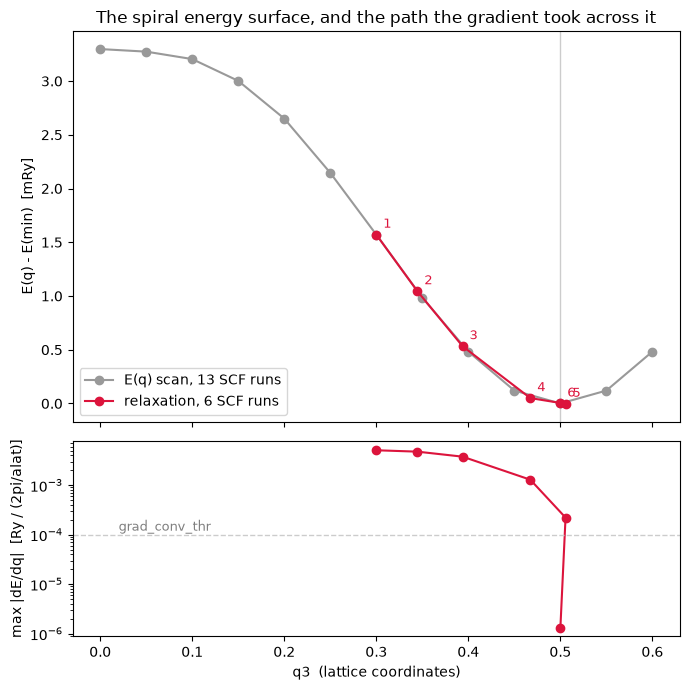

In [9]:
scan_q = np.linspace(0.0, 0.6, 13)
scan = run_spiral_scan(
    chain_at(0.0, ecutwfc=40.0)[0], pseudos,
    np.column_stack([np.zeros_like(scan_q), np.zeros_like(scan_q), scan_q]),
    conv_thr=1e-10, mixing_beta=0.3, max_iterations=300,
)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})
reference = scan.energies.min()
top.plot(scan_q, 1e3 * (scan.energies - reference), "o-", color="0.6",
         label="E(q) scan, 13 SCF runs")
path = np.array([[s.wavevector[2], s.total_energy] for s in relaxed.steps])
top.plot(path[:, 0], 1e3 * (path[:, 1] - reference), "o-", color="crimson",
         label=f"relaxation, {relaxed.nsteps} SCF runs")
for index, (q3, energy) in enumerate(path, start=1):
    top.annotate(str(index), (q3, 1e3 * (energy - reference)),
                 textcoords="offset points", xytext=(5, 5), color="crimson", fontsize=9)
top.axvline(0.5, color="0.8", lw=1, zorder=0)
top.set_ylabel("E(q) - E(min)  [mRy]")
top.legend()
top.set_title("The spiral energy surface, and the path the gradient took across it")

bottom.plot(path[:, 0], [s.max_gradient for s in relaxed.steps], "o-", color="crimson")
bottom.axhline(1e-4, color="0.8", lw=1, ls="--")
bottom.set_yscale("log")
bottom.set_xlabel("q3  (lattice coordinates)")
bottom.set_ylabel("max |dE/dq|  [Ry / (2pi/alat)]")
bottom.annotate("grad_conv_thr", (0.02, 1.2e-4), color="0.5", fontsize=9)
fig.tight_layout()

## What this is for

The chain was chosen because its answer is known: the minimum is at a commensurate
wavevector that a doubled cell reproduces exactly, which is what makes it a test rather
than a demonstration.

The point of the machinery is the case where that is not true. An incommensurate spiral —
a `q` that is not a ratio of small integers — has no supercell, so its pitch cannot be
found by relaxing anything else. Here it is one gradient and a BFGS loop, with nothing
derived by hand for either, because the energy was written down as a function of `q` and
differentiated.

The same sentence describes the force (notebook 09), `force_hub` (notebook 13), and the
five hand-derived magnetic-field potentials of notebook 11. It is the reason the code is
written in JAX.